In [127]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [128]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np

In [ ]:
# INPUT
img_path = input("Enter image path: ")
image = cv.imread(img_path)
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

In [150]:
# Converting to float for easy calculations
img = image.astype(np.float32) / 255.0

In [151]:
# Taking input from the users
cb_type = input("Enter color blindness type: ").lower()
severity = float(input("Enter severity: "))
a = severity / 100.0

Enter color blindness type: protanopia
Enter severity: 100


In [152]:
matrices = {
    "protanopia": np.array([
        [0.567, 0.433, 0],
        [0.558, 0.442, 0],
        [0.000, 0.242, 0.758]
    ]),

    "deuteranopia": np.array([
        [0.80, 0.20, 0],
        [0.258, 0.742, 0],
        [0, 0.142, 0.858]
    ]),

    "tritanopia": np.array([
        [0.950, 0.050, 0],
        [0.000, 0.433, 0.567],
        [0.000, 0.475, 0.525]
    ])
}

In [153]:
if cb_type not in matrices:
    print("Invalid type")
    exit()

M = matrices[cb_type]
print(cb_type)
print("selected matrix \n",M)

protanopia
selected matrix 
 [[0.567 0.433 0.   ]
 [0.558 0.442 0.   ]
 [0.    0.242 0.758]]


In [154]:
# Applying Matrix Transformation
transformed = img @ M.T

In [155]:
# applying the blend based on severity
final = (1 - a) * img + a * transformed

In [156]:
# Convert back to 0-255
limit = np.clip(final * 255, 0, 255)
final = limit.astype(np.uint8)
image = cv.cvtColor(image, cv.COLOR_RGB2BGR)
final = cv.cvtColor(final, cv.COLOR_RGB2BGR)

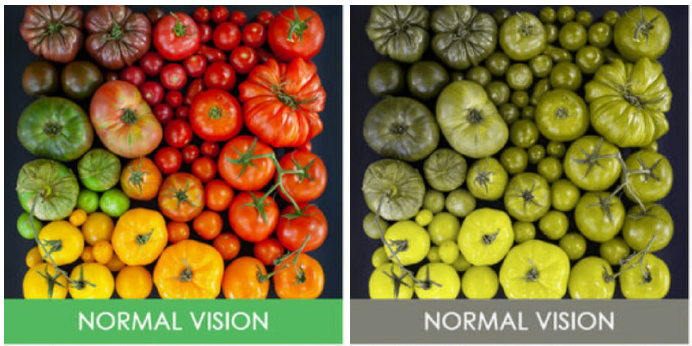

-1

In [157]:
# OUTPUT
combined = np.concatenate((image, final), axis=1)

cv2_imshow(combined)
cv.waitKey(1000)
